# AARFI vs. Crisp Apriori — Runtime Benchmark

Benchmarks wall-clock time per dataset for:
- `AARFI_F` with operators $(T_{LK}, I_p)$
- Crisp Apriori baseline (`mlxtend` + `association_rules` + redundancy pruning)

The x-axis proxy for dataset complexity is $N \times I$, where $N$ is the number of rows and $I = F \cdot L$ is the total number of fuzzy items (features × linguistic labels). Parameters are fixed across all datasets: `min_cov=min_supp=0.3`, `min_conf=0.8`, `max_feat=3`, `n_labels=3`.

In [7]:
import time
import statistics
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

import FIRM.base.fuzzy_data as fuzzy_data
import FIRM.base.operators.implications as implications
import FIRM.base.operators.tnorms as tnorms
from FIRM.methods.AARFI import AARFI_F
from mlxtend.frequent_patterns import apriori as mlxtend_apriori, association_rules

In [8]:
def process_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        s = out[col]

        if pd.api.types.is_integer_dtype(s):
            out[col] = s.astype('float64')
            continue

        is_cat_like = (
            pd.api.types.is_object_dtype(s)
            or isinstance(s.dtype, pd.CategoricalDtype)
            or pd.api.types.is_string_dtype(s)
        )
        if is_cat_like:
            n_unique = s.nunique(dropna=True)
            if n_unique > 10:
                top10 = s.value_counts(dropna=True).index[:10]
                out[col] = s.where(s.isna() | s.isin(top10), 'Unknown').astype('object')
            else:
                out[col] = s.astype('object')

    return out


def _tokens_from_group(group):
    if group is None:
        return []
    if isinstance(group, (set, frozenset, list, tuple)):
        return [str(x).strip() for x in group if str(x).strip()]
    if pd.isna(group):
        return []

    s = str(group).strip()
    if not s:
        return []
    if s.startswith('(') and s.endswith(')'):
        s = s[1:-1].strip()
    return [t.strip() for t in s.split(',')] if ',' in s else [s]


def _attach_tokens_for_pruning(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    out = df.copy()
    out['ant_tokens'] = out['antecedents'].apply(_tokens_from_group)
    out['con_token'] = out['consequents'].apply(lambda c: (_tokens_from_group(c)[0] if _tokens_from_group(c) else ''))
    return out


def prune_redundant_df(df: pd.DataFrame, epsilon: float) -> pd.DataFrame:
    if df.empty:
        return df

    groups = []
    for _, group in df.groupby('con_token', sort=False):
        group_sorted = group.sort_values('n_antecedents', kind='mergesort')
        kept_idx = []
        kept_ants = []
        kept_conf = []

        for idx, row in group_sorted.iterrows():
            A1 = set(row['ant_tokens'])
            c1 = float(row['confidence'])
            redundant = False

            for A2, c2 in zip(kept_ants, kept_conf):
                if A2.issubset(A1) and abs(c1 - c2) < epsilon:
                    redundant = True
                    break

            if not redundant:
                kept_idx.append(idx)
                kept_ants.append(A1)
                kept_conf.append(c1)

        groups.append(group_sorted.loc[kept_idx])

    return pd.concat(groups, ignore_index=True) if groups else df.iloc[0:0]


def make_dataset(csv_name: str, n_labels: int = 3):
    csv_path = Path('../assets') / csv_name
    dataset = process_df(pd.read_csv(csv_path, sep=','))

    int_cols = dataset.select_dtypes(include=['int']).columns
    if len(int_cols):
        dataset[int_cols] = dataset[int_cols].astype(float)

    labels = ['L', 'M', 'H'] if n_labels == 3 else [f'L{i+1}' for i in range(n_labels)]
    fdata = fuzzy_data.FuzzyDataQuantiles(csv_name, dataset, n_labels, labels)

    total_labels = int(sum(len(fv.get_labels) for fv in fdata.fv_list))
    onehot_cols = int(sum(dataset[col].nunique(dropna=True) for col in dataset.columns))

    meta = {
        'rows': int(len(dataset)),
        'cols': int(len(dataset.columns)),
        'total_labels': total_labels,
        'onehot_cols': onehot_cols,
        'complexity': int(len(dataset) * total_labels),
    }
    return dataset, fdata, meta


def crisp_apriori_timing(
    dataset: pd.DataFrame,
    fdata,
    min_supp: float,
    min_conf: float,
    max_feat: int,
    prune_epsilon: float,
):
    t0 = time.perf_counter()

    data = dataset.copy()
    for i in range(len(fdata.fv_list)):
        data[dataset.columns[i]] = dataset[dataset.columns[i]].map(
            lambda x: fdata.fv_list[i].eval_max_fuzzy_set(x)
        )

    encoded = pd.get_dummies(data, columns=data.columns)

    df_freq = mlxtend_apriori(
        encoded,
        min_support=min_supp,
        use_colnames=True,
        verbose=0,
        max_len=max_feat + 1,
        low_memory=True,
    )

    if df_freq.empty:
        df_rules_filtered = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'confidence'])
    else:
        df_ar = association_rules(df_freq, metric='confidence', min_threshold=min_conf)
        df_rules_filtered = df_ar[
            (df_ar['antecedents'].apply(len) <= max_feat)
            & (df_ar['consequents'].apply(len) <= 1)
        ].reset_index(drop=True)

        if not df_rules_filtered.empty:
            df_rules_filtered = df_rules_filtered.assign(
                n_antecedents=df_rules_filtered['antecedents'].apply(len)
            )
            df_rules_filtered = _attach_tokens_for_pruning(df_rules_filtered)
            df_rules_filtered = prune_redundant_df(df_rules_filtered, prune_epsilon)
            df_rules_filtered = df_rules_filtered[
                (df_rules_filtered['support'] >= min_supp) & (df_rules_filtered['confidence'] >= min_conf)
            ].reset_index(drop=True)

    dt = time.perf_counter() - t0
    return dt, int(len(df_rules_filtered)), int(encoded.shape[1])


def aarfi_f_timing(
    dataset: pd.DataFrame,
    fdata,
    T,
    I,
    F,
    min_cov: float,
    min_supp: float,
    min_conf: float,
    max_feat: int,
    row_chunk: int,
    prune_epsilon: float,
    separable_F: bool,
    n_jobs: int = 1,
):
    t0 = time.perf_counter()
    rules, _ = AARFI_F(
        dataset,
        fdata,
        T=T,
        I=I,
        F=F,
        min_cov=min_cov,
        min_supp=min_supp,
        min_conf=min_conf,
        max_feat=max_feat,
        chunk_rows=row_chunk,
        prune_epsilon=prune_epsilon,
        separable_F=separable_F,
        n_jobs=n_jobs,
        verbose=False,
    )
    dt = time.perf_counter() - t0
    return dt, int(len(rules.rule_list))

In [6]:
DATASETS = ['iris.csv', 'wdbc.csv', 'vehicle.csv', 'abalone.csv', 'magic.csv', 'online_news.csv', 'global_house.csv']

CFG = {
    'repeats':       1,
    'min_cov':       0.3,
    'min_supp':      0.3,
    'min_conf':      0.8,
    'max_feat':      3,
    'n_labels':      3,
    'row_chunk':     100_000,
    'prune_epsilon': 0.05,
    'n_jobs':        -1,
}

p_ip = 0.01
OPERATOR_VARIANTS = [
    {
        'name':        '(TLK,Ip)',
        'T':           lambda x, y: np.maximum(x + y - 1, 0),
        'I':           lambda x, y: 1 - x + x * np.power(y, p_ip),
        'F':           lambda x, y: x * np.power(y, p_ip),
        'separable_F': True,
    },
]

print('Config:', CFG)
rows = []

for name in DATASETS:
    dataset, fdata, meta = make_dataset(name, n_labels=CFG['n_labels'])
    print(f"\n{name} | N={meta['rows']} F={meta['cols']} I={meta['total_labels']} complexity={meta['complexity']}")

    row = {
        'Dataset':     name,
        'Rows':        meta['rows'],
        'Cols':        meta['cols'],
        'TotalLabels': meta['total_labels'],
        'OneHotCols':  meta['onehot_cols'],
        'Complexity':  meta['complexity'],
    }

    for op in OPERATOR_VARIANTS:
        times, rule_counts = [], []
        for _ in range(CFG['repeats']):
            dt, n_rules = aarfi_f_timing(
                dataset, fdata,
                T=op['T'], I=op['I'], F=op['F'],
                min_cov=CFG['min_cov'], min_supp=CFG['min_supp'], min_conf=CFG['min_conf'],
                max_feat=CFG['max_feat'], row_chunk=CFG['row_chunk'],
                prune_epsilon=CFG['prune_epsilon'], separable_F=op['separable_F'],
                n_jobs=CFG['n_jobs'],
            )
            times.append(dt); rule_counts.append(n_rules)
        row[f"AARFI_{op['name']}_MedianSec"]   = float(statistics.median(times))
        row[f"AARFI_{op['name']}_RulesMedian"] = int(statistics.median(rule_counts))
        print(f"  AARFI {op['name']}: {statistics.median(times):.4f}s  rules={int(statistics.median(rule_counts))}")

    crisp_times, crisp_rules = [], []
    for _ in range(CFG['repeats']):
        dt_c, n_c, onehot_cols = crisp_apriori_timing(
            dataset, fdata,
            min_supp=CFG['min_supp'], min_conf=CFG['min_conf'],
            max_feat=CFG['max_feat'], prune_epsilon=CFG['prune_epsilon'],
        )
        crisp_times.append(dt_c); crisp_rules.append(n_c)
    row['Crisp_MedianSec']   = float(statistics.median(crisp_times))
    row['Crisp_RulesMedian'] = int(statistics.median(crisp_rules))
    row['OneHotCols']        = onehot_cols
    print(f"  Crisp Apriori:   {statistics.median(crisp_times):.4f}s  rules={int(statistics.median(crisp_rules))}")
    rows.append(row)

benchmark_df = pd.DataFrame(rows).sort_values('Complexity').reset_index(drop=True)
benchmark_df.to_csv(Path('../assets/benchmark_results.csv'), index=False)
print('\nDone. Results saved to assets/benchmark_results.csv')

Config: {'repeats': 1, 'min_cov': 0.3, 'min_supp': 0.3, 'min_conf': 0.8, 'max_feat': 3, 'n_labels': 3, 'row_chunk': 100000, 'prune_epsilon': 0.05, 'n_jobs': -1}

iris.csv | N=150 F=5 I=15 complexity=2250
  AARFI (TLK,Ip): 0.0189s  rules=24
  Crisp Apriori:   0.0438s  rules=20

wdbc.csv | N=569 F=11 I=32 complexity=18208
  AARFI (TLK,Ip): 0.0373s  rules=56
  Crisp Apriori:   0.1113s  rules=39

vehicle.csv | N=846 F=19 I=58 complexity=49068
  AARFI (TLK,Ip): 0.1309s  rules=184
  Crisp Apriori:   0.2775s  rules=94

abalone.csv | N=4174 F=9 I=27 complexity=112698
  AARFI (TLK,Ip): 0.1669s  rules=87
  Crisp Apriori:   0.4436s  rules=105

magic.csv | N=19020 F=11 I=32 complexity=608640
  AARFI (TLK,Ip): 0.8453s  rules=43
  Crisp Apriori:   1.9403s  rules=13

online_news.csv | N=39644 F=59 I=177 complexity=7016988
  AARFI (TLK,Ip): 11.1827s  rules=6587
  Crisp Apriori:   134.3675s  rules=1914

global_house.csv | N=200000 F=24 I=91 complexity=18200000
  AARFI (TLK,Ip): 19.3852s  rules=389
  Cr

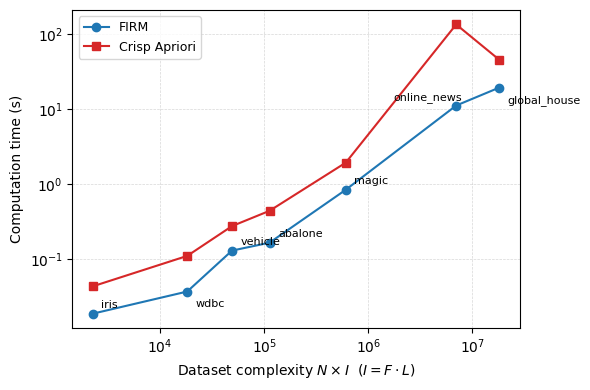

In [9]:
plt.style.use('default')

benchmark_df = pd.read_csv(Path('../assets/benchmark_results.csv')).sort_values('Complexity').reset_index(drop=True)

METHODS = {
    'AARFI_(TLK,Ip)_MedianSec': ('FIRM', '#1f77b4', 'o'),
    'Crisp_MedianSec':           ('Crisp Apriori',          '#d62728', 's'),
}

LABEL_OFFSETS = {
    'iris':         (  6,   4),
    'wdbc':         (  6, -11),
    'vehicle':      (  6,   4),
    'abalone':      (  6,   4),
    'magic':        (  6,   4),
    'online_news':  (-45,   4),
    'global_house': (  6, -11),
}

fig, ax = plt.subplots(figsize=(6, 4))

for col, (label, color, marker) in METHODS.items():
    ax.plot(
        benchmark_df['Complexity'], benchmark_df[col],
        label=label, color=color, marker=marker,
        linewidth=1.5, markersize=6,
    )

ref_col = 'AARFI_(TLK,Ip)_MedianSec'
for _, row in benchmark_df.iterrows():
    name = row['Dataset'].replace('.csv', '')
    ox, oy = LABEL_OFFSETS.get(name, (6, 4))
    ax.annotate(name, xy=(row['Complexity'], row[ref_col]),
                xytext=(ox, oy), textcoords='offset points',
                fontsize=8, color='black', fontfamily='sans-serif')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Dataset complexity $N \times I$  $(I = F \cdot L)$', fontsize=10)
ax.set_ylabel('Computation time (s)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.5)
ax.minorticks_off()

plt.tight_layout()
plt.savefig(Path('../assets/benchmark_plot.pdf'), bbox_inches='tight', facecolor='white')
plt.savefig(Path('../assets/benchmark_plot.png'), bbox_inches='tight', dpi=300, facecolor='white')
plt.show()